In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from statsmodels.tsa.seasonal import seasonal_decompose

pd.set_option("display.max_columns" , None)

archivo = Path( "Laboratorio 1. Series de Tiempo 2026 - Base_Migracion_2009-2026jun.xlsx" )

datos = pd.read_excel(archivo)

print("dataset:", datos.shape)
print(datos.columns.tolist())


dataset: (161036, 13)
['Año', 'Mes cod', 'Mes', 'Vía', 'Frontera', 'País', 'Región', 'Región dos', 'Regiones OMT', 'MCEO', 'Agrupación Residencia', 'Tipo de Viajero', 'Viajero']


In [8]:
datos["Año"] = pd.to_numeric( datos[ "Año"], errors ="coerce")
datos["Mes cod"] = pd.to_numeric(datos["Mes cod"], errors ="coerce")
datos["Viajero"] = pd.to_numeric( datos["Viajero"] , errors ="coerce")

datos["Fecha"] = pd.to_datetime(
    {"year": datos["Año"], "month": datos["Mes cod"], "day": 1},

    errors ="coerce"
)

In [9]:
tipos_seleccionados = ["Turista", "Excursionista"]

datos_visitantes = datos[datos["Tipo de Viajero"].isin(tipos_seleccionados)].copy()

datos["Tipo de Viajero"].isin(tipos_seleccionados)


0          True
1          True
2          True
3          True
4          True
          ...  
161031     True
161032    False
161033     True
161034    False
161035     True
Name: Tipo de Viajero, Length: 161036, dtype: bool

In [10]:
datos_visitantes["Vía"].value_counts(dropna=False)

Vía
Terrestre    105111
Aérea         24508
Marítima       8023
Name: count, dtype: int64

In [11]:
series_vias = (
    datos_visitantes
    .dropna(subset=["Fecha", "Vía", "Viajero"])
    .groupby(["Fecha", "Vía"])["Viajero"]
    .sum()
    .unstack("Vía")
    .sort_index()
    .asfreq("MS")
)

In [12]:
print("Inicio:", series_vias.index.min())
print("Fin:", series_vias.index.max())
print("Frecuencia:", series_vias.index.freqstr)
print("Número de meses:", len(series_vias))

print("\nColumnas creadas:")
print(series_vias.columns.tolist())

print("\nValores faltantes por vía:")
print(series_vias.isna().sum())

series_vias.head()

Inicio: 2009-01-01 00:00:00
Fin: 2026-06-01 00:00:00
Frecuencia: MS
Número de meses: 210

Columnas creadas:
['Aérea', 'Marítima', 'Terrestre']

Valores faltantes por vía:
Vía
Aérea          0
Marítima     114
Terrestre      0
dtype: int64


Vía,Aérea,Marítima,Terrestre
Fecha,,,
2009-01-01,81693.0,809.0,67442.029345
2009-02-01,70099.0,938.0,56266.692203
2009-03-01,84494.0,1190.0,73111.673819
2009-04-01,80618.0,1498.0,89897.467694
2009-05-01,64621.0,1040.0,58898.524351


In [13]:
serie_aerea = series_vias["Aérea" ]
serie_terrestre = series_vias["Terrestre" ]
serie_maritima = series_vias["Marítima" ]

serie_aerea.name =  "via_aerea"
serie_terrestre.name =  "via_terrestre"
serie_maritima.name =  "via_maritima"

for nombre, serie in { "Aérea": serie_aerea,
    "Terrestre": serie_terrestre ,
    "Marítima" :  serie_maritima
}.items():

    print(f"\nvía {nombre} " )
    print("inicio:" , serie.index.min())
    print("fin :" , serie.index.max())
    print("Frecuencia: " , serie.index.freqstr)
    print("cantidad de meses:", len(serie))
    print("valores que faltan:", serie.isna().sum() )


vía Aérea 
inicio: 2009-01-01 00:00:00
fin : 2026-06-01 00:00:00
Frecuencia:  MS
cantidad de meses: 210
valores que faltan: 0

vía Terrestre 
inicio: 2009-01-01 00:00:00
fin : 2026-06-01 00:00:00
Frecuencia:  MS
cantidad de meses: 210
valores que faltan: 0

vía Marítima 
inicio: 2009-01-01 00:00:00
fin : 2026-06-01 00:00:00
Frecuencia:  MS
cantidad de meses: 210
valores que faltan: 114


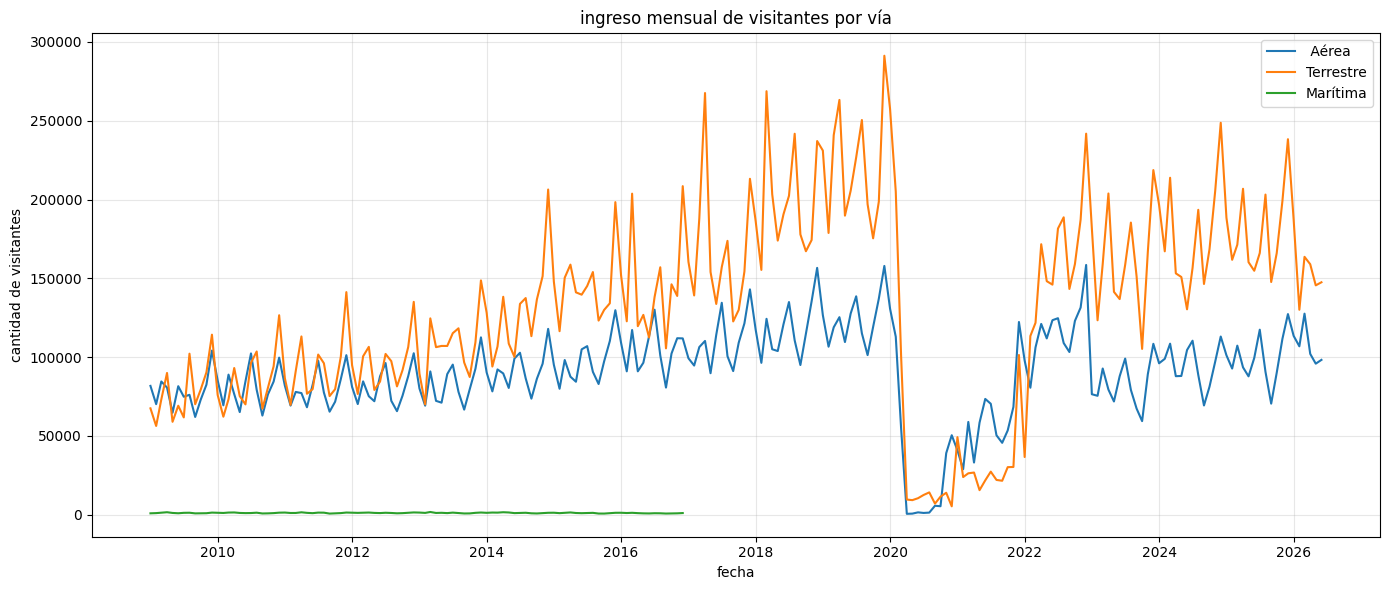

In [14]:
plt.figure(figsize= (14 , 6) ) 

plt.plot( serie_aerea.index , serie_aerea, label= " Aérea" )

plt.plot( serie_terrestre.index, serie_terrestre, label= "Terrestre" )

plt.plot( serie_maritima.index, serie_maritima , label= "Marítima")

plt.title("ingreso mensual de visitantes por vía")
plt.xlabel("fecha")
plt.ylabel("cantidad de visitantes")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

revisar dónde hacen falta los marítimos

In [15]:
fechas_faltantes_maritima = serie_maritima[ serie_maritima.isna()]

print("Primer mes faltante:", fechas_faltantes_maritima.index.min() )
print("Último mes faltante:", fechas_faltantes_maritima.index.max() )
print("Cantidad de meses faltantes:" , len(fechas_faltantes_maritima) )

fechas_faltantes_maritima.head(15)

Primer mes faltante: 2017-01-01 00:00:00
Último mes faltante: 2026-06-01 00:00:00
Cantidad de meses faltantes: 114


Fecha
2017-01-01   NaN
2017-02-01   NaN
2017-03-01   NaN
2017-04-01   NaN
2017-05-01   NaN
2017-06-01   NaN
2017-07-01   NaN
2017-08-01   NaN
2017-09-01   NaN
2017-10-01   NaN
2017-11-01   NaN
2017-12-01   NaN
2018-01-01   NaN
2018-02-01   NaN
2018-03-01   NaN
Freq: MS, Name: via_maritima, dtype: float64

In [16]:
serie_maritima.dropna().tail(15)



Fecha
2015-10-01     646.0
2015-11-01     887.0
2015-12-01    1138.0
2016-01-01    1164.0
2016-02-01     994.0
2016-03-01    1133.0
2016-04-01     917.0
2016-05-01     784.0
2016-06-01     728.0
2016-07-01     864.0
2016-08-01     826.0
2016-09-01     662.0
2016-10-01     730.0
2016-11-01     801.0
2016-12-01     975.0
Freq: MS, Name: via_maritima, dtype: float64

In [17]:
faltantes_maritima_por_anio = (
    serie_maritima
    .isna()
    .groupby(serie_maritima.index.year )
    .sum( )
)

faltantes_maritima_por_anio

Fecha
2009     0
2010     0
2011     0
2012     0
2013     0
2014     0
2015     0
2016     0
2017    12
2018    12
2019    12
2020    12
2021    12
2022    12
2023    12
2024    12
2025    12
2026     6
Name: via_maritima, dtype: int64

In [18]:
serie_maritima_disponible = serie_maritima.dropna()

print("Inicio:", serie_maritima_disponible.index.min())
print("Fin:", serie_maritima_disponible.index.max())
print("Frecuencia:", serie_maritima_disponible.index.freqstr)
print("Cantidad de meses:", len(serie_maritima_disponible))

Inicio: 2009-01-01 00:00:00
Fin: 2016-12-01 00:00:00
Frecuencia: MS
Cantidad de meses: 96


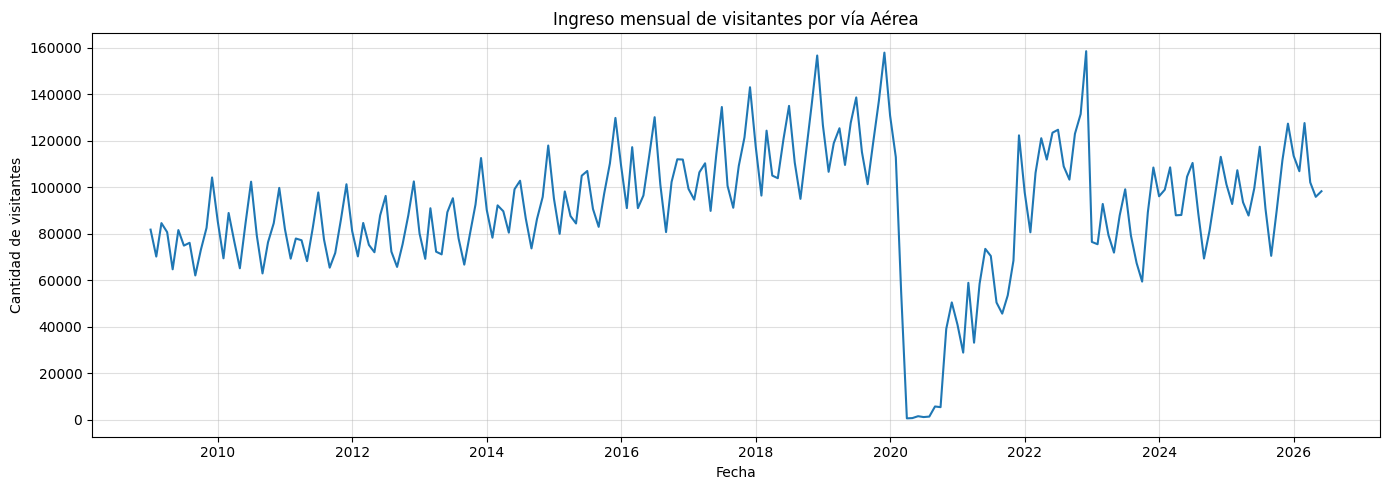

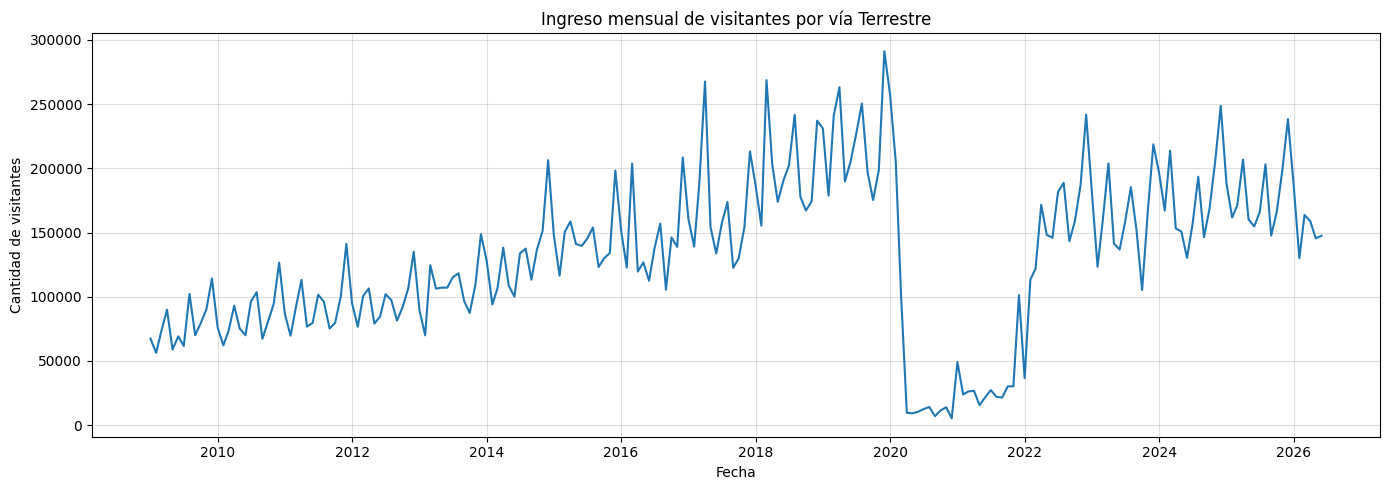

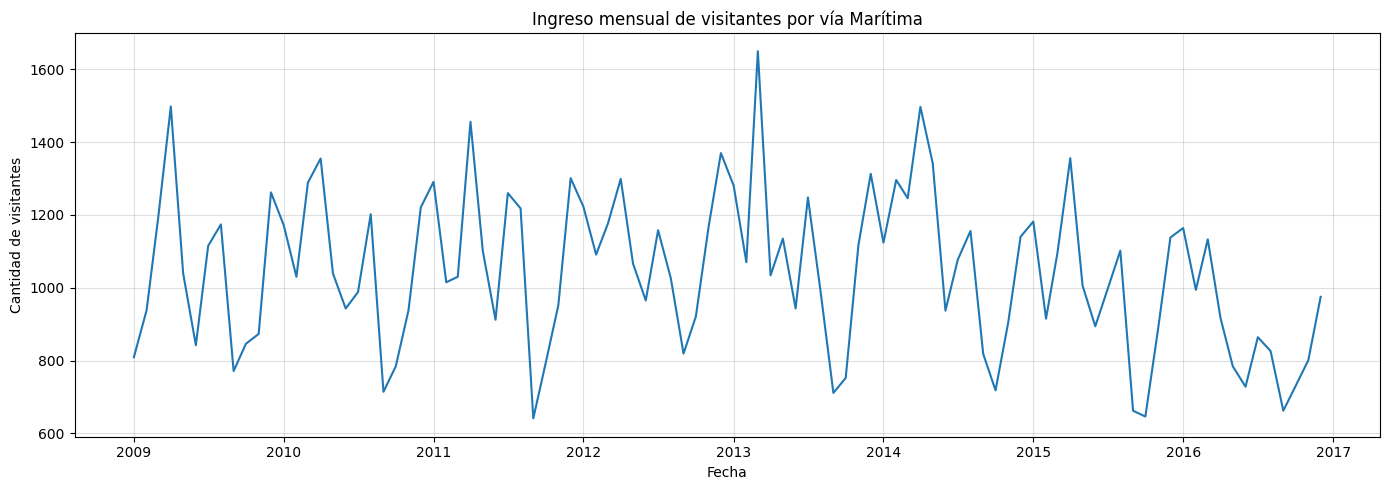

In [19]:
series_por_via = {
    "Aérea": serie_aerea,
    "Terrestre": serie_terrestre,
    "Marítima": serie_maritima_disponible
}

for nombre, serie in series_por_via.items():

    plt.figure(figsize= (14 , 5) )

    plt.plot(serie.index, serie )

    plt.title(f"Ingreso mensual de visitantes por vía {nombre}" )
    plt.xlabel("Fecha")
    plt.ylabel("Cantidad de visitantes")
    plt.grid(alpha = 0.4 )
    plt.tight_layout()
    plt.show()

### medias móviles de 12 meses

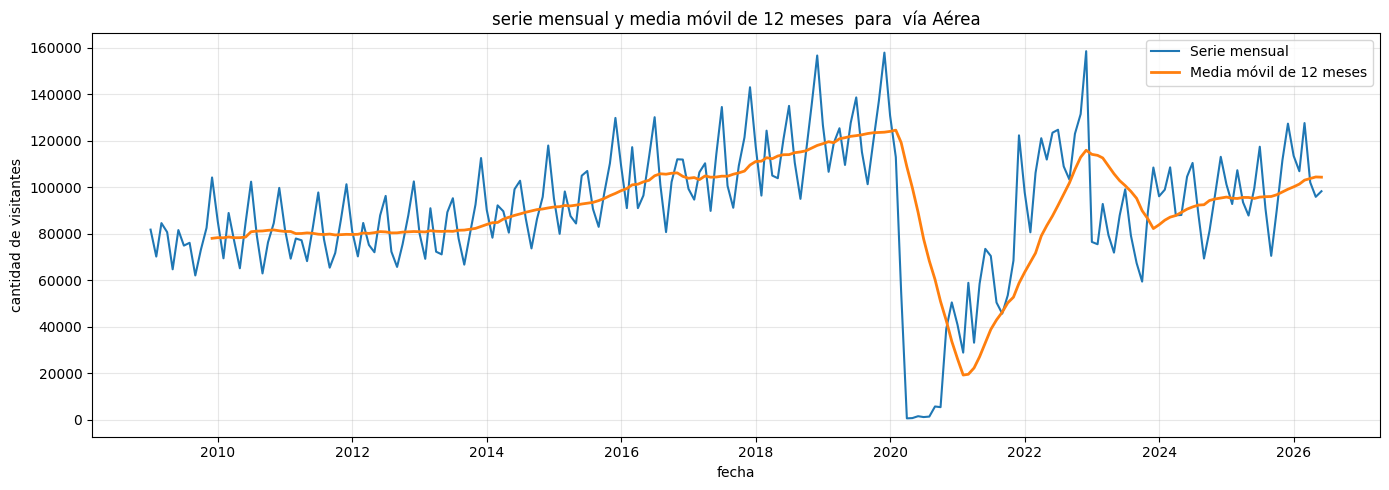

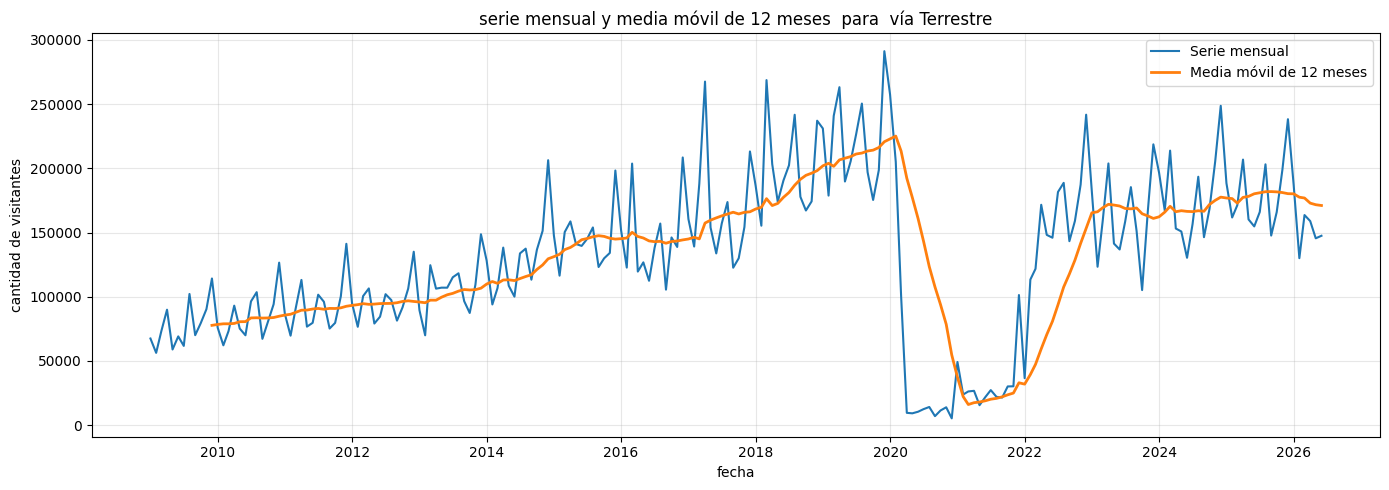

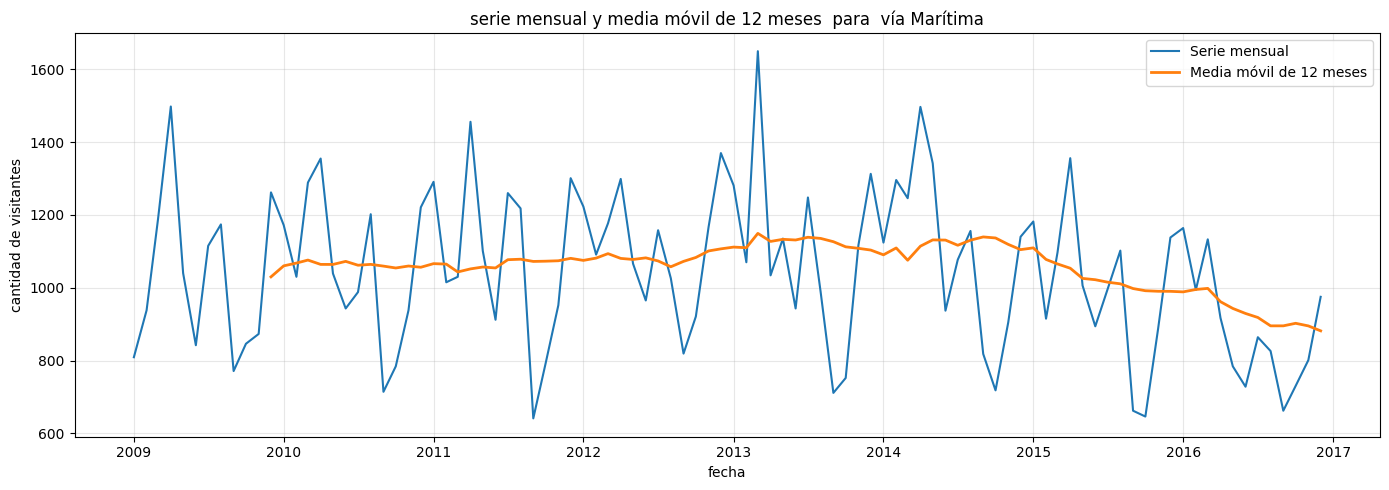

In [20]:
series_por_via = {
    "Aérea": serie_aerea,
    "Terrestre": serie_terrestre,
    "Marítima": serie_maritima_disponible
}

for nombre, serie in series_por_via.items():

    media_movil_12 = serie.rolling(12 ).mean()

    plt.figure(figsize = (14, 5) )

    plt.plot(serie.index, serie, label= "Serie mensual" )

    plt.plot(
        media_movil_12.index,
        media_movil_12,
        linewidth=2,
        label="Media móvil de 12 meses"
    )

    plt.title(
        f"serie mensual y media móvil de 12 meses  para  vía {nombre }"
    )
    plt.xlabel("fecha")
    plt.ylabel("cantidad de visitantes")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

el 70/30

In [21]:
cantidad_entrenamiento_aerea = int( len(serie_aerea) *  0.70 )
cantidad_entrenamiento_terrestre =  int( len( serie_terrestre) *  0.70 )
cantidad_entrenamiento_maritima = int( len(serie_maritima_disponible ) * 0.70 )

entrenamiento_aerea = serie_aerea.iloc[:cantidad_entrenamiento_aerea ]
prueba_aerea = serie_aerea.iloc[cantidad_entrenamiento_aerea:]

entrenamiento_terrestre = serie_terrestre.iloc[:cantidad_entrenamiento_terrestre]
prueba_terrestre = serie_terrestre.iloc[cantidad_entrenamiento_terrestre:]

entrenamiento_maritima = serie_maritima_disponible.iloc[:cantidad_entrenamiento_maritima]
prueba_maritima = serie_maritima_disponible.iloc[ cantidad_entrenamiento_maritima:]

In [22]:
series_divididas = {
    "aérea": ( entrenamiento_aerea, prueba_aerea),
    "terrestre": (entrenamiento_terrestre, prueba_terrestre ),
    "marítima": (entrenamiento_maritima, prueba_maritima)
}

for nombre, (entrenamiento, prueba) in series_divididas.items():

    print(f"\nVía {nombre}")

    print( "Observaciones de entrenamiento:", len(entrenamiento))
    print("Observaciones de prueba:" ,len(prueba))

    print( "Fin del entrenamiento:" , entrenamiento.index.max())
    print("Inicio de la prueba:",prueba.index.min() )


Vía aérea
Observaciones de entrenamiento: 147
Observaciones de prueba: 63
Fin del entrenamiento: 2021-03-01 00:00:00
Inicio de la prueba: 2021-04-01 00:00:00

Vía terrestre
Observaciones de entrenamiento: 147
Observaciones de prueba: 63
Fin del entrenamiento: 2021-03-01 00:00:00
Inicio de la prueba: 2021-04-01 00:00:00

Vía marítima
Observaciones de entrenamiento: 67
Observaciones de prueba: 29
Fin del entrenamiento: 2014-07-01 00:00:00
Inicio de la prueba: 2014-08-01 00:00:00


In [23]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import keras_tuner as kt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [24]:
semilla = 42

os.environ["PYTHONHASHSEED"] = str(semilla)
random.seed(semilla)
np.random.seed(semilla)
tf.random.set_seed(semilla)

In [ ]:
print("el train:", len(entrenamiento_aerea))
print("test:", len(prueba_aerea))


print("el train :", len(entrenamiento_terrestre))
print("test:", len(prueba_terrestre) )

Aérea:
Entrenamiento: 147
Prueba: 63

Terrestre:
Entrenamiento: 147
Prueba: 63
